In [1]:
import os
import cv2
import sys
import math
import warnings
import numpy as np
from zipfile import ZipFile

import pandas as pd

#import gdal
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

from jupyterthemes import jtplot
jtplot.style()

from scipy import ndimage as ndi
from skimage import feature

from PIL import Image
from IPython.display import display

if not sys.warnoptions:
    warnings.simplefilter("ignore")

%matplotlib inline

In [2]:
# Load path to the libs folder. 
import os
# 获取项目根目录（notebooks 的父目录）
current_dir = os.getcwd()
# 如果当前在 notebooks 目录，则向上一级；否则使用当前目录
if os.path.basename(current_dir) == 'notebooks':
    project_root = os.path.dirname(current_dir)
else:
    project_root = current_dir
path_libs = os.path.join(project_root, 'src')
sys.path.insert(0, path_libs)
print(f'Added to Python path: {path_libs}')

Added to Python path: /Users/sohpie/Documents/GitHub/CSC_591_fingerprint_authentication/src


In [3]:
from libs.enhancing import *
from libs.basics import *
from libs.processing import *

# Sourcing

In [4]:
import importlib
import libs.basics
importlib.reload(libs.basics)

<module 'libs.basics' from '/Users/sohpie/Documents/GitHub/CSC_591_fingerprint_authentication/src/libs/basics.py'>

In [5]:
display_dataset('A', size=1.2, users=3)

In [6]:
display_dataset('B', size=1.2, users=3)

In [7]:
display_dataset('A', size=3, users=1, samples=4)
display_dataset('B', size=4, users=1, samples=4)

# Pre-processing

In [11]:
path = '../Project-Data/train/000_R0_0.bmp'

In [12]:
img = cv2.imread(path, 0)
# DFT computation tends to be faster on arrays with sizes of a power of 2, or a multiple of 2, 3, 5 
# For using an optimal shape, padding might be required (0s)
print(f'Base image shape: {img.shape}')
print(f'Optiml image shape: {(cv2.getOptimalDFTSize(img.shape[0]), cv2.getOptimalDFTSize(img.shape[1]))}')

Base image shape: (356, 328)
Optiml image shape: (360, 360)


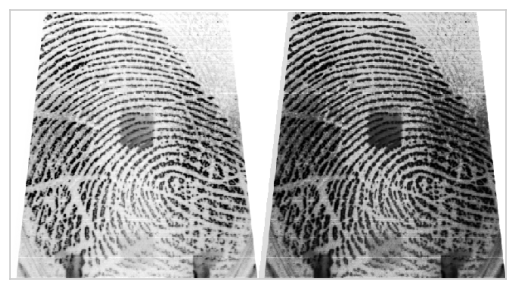

In [13]:
# Before and after equalisation.
# https://en.wikipedia.org/wiki/Histogram_equalization
img_eq = histogram_equalisation(img)
display_image(np.hstack((img, img_eq)))

# img_eq = cv.equalizeHist(img)
# display_image(np.hstack((img, img_eq)))

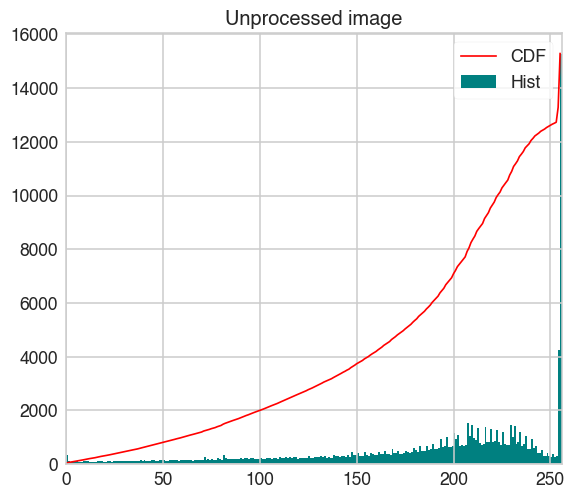

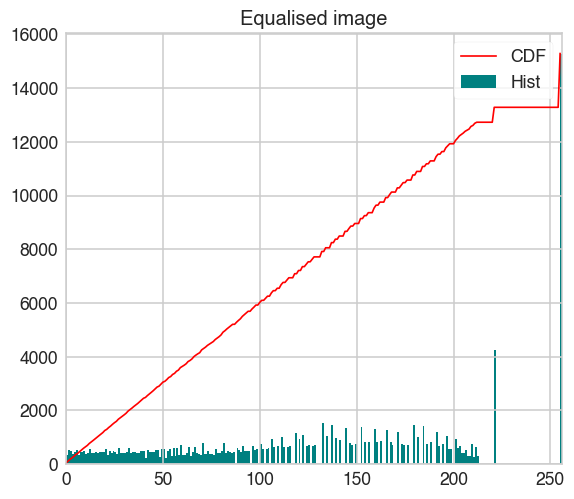

In [14]:
# Equalisation visualisation. 
color_range = 256

plt.plot(cdf_normalised(img, color_range), color = 'red')
plt.hist(img.flatten(), color_range, [0, color_range], color = 'teal')
plt.xlim([0, color_range])
plt.legend(('CDF','Hist'))
plt.title('Unprocessed image')
plt.show()

plt.plot(cdf_normalised(img_eq, color_range), color = 'red')
plt.hist(img_eq.flatten(), color_range, [0, color_range], color = 'teal')
plt.xlim([0, color_range])
plt.legend(('CDF','Hist'))
plt.title('Equalised image')
plt.show()

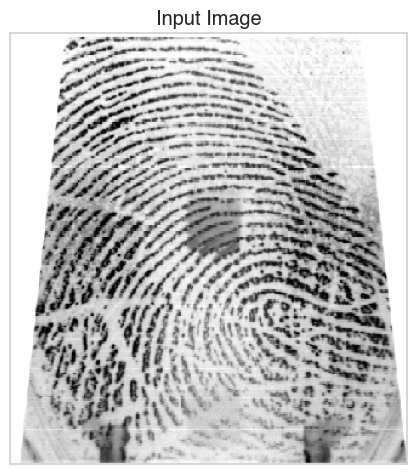

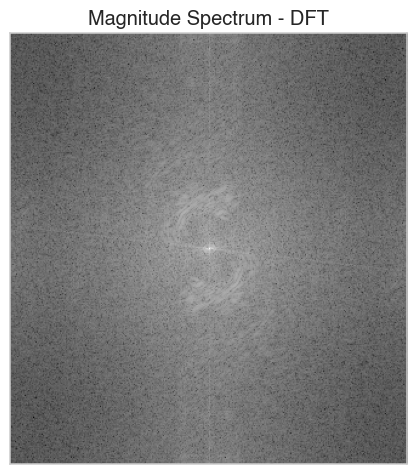

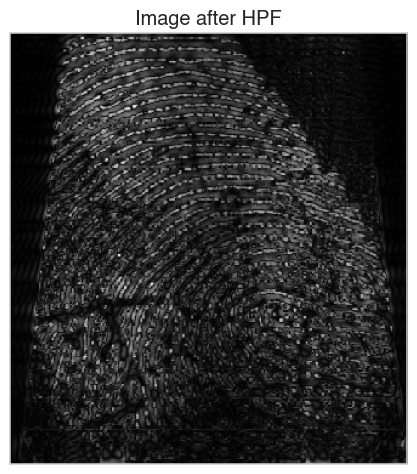

In [15]:
magnitude_spectrum = 20 * np.log(np.abs(fourier_transform(img)))
img_hpf = high_pass_filter(img)

display_image(img, 'Input Image')
display_image(magnitude_spectrum, 'Magnitude Spectrum - DFT')
display_image(img_hpf, 'Image after HPF')

# Feature extraction
We extract the fingerprint ridges by removing the background and thinning the ridges. We also extract ridge endings and bifurcations (minutiae).

In [16]:
from scipy import ndimage, signal

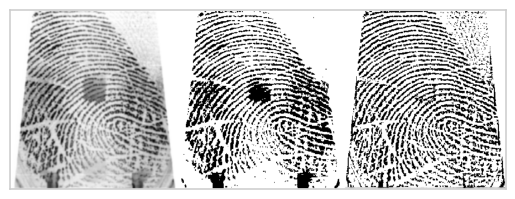

Threshold OTSU: 156.0


In [17]:
# Binarise image
# Direct application tends to obfuscate ridges. The details are much better handled by a 
# rolling window approach as presented in 'binarise' function.
img_bin = binarise(img)
img_blur = cv2.GaussianBlur(img, (5,5), 0)
threshold, img_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

display_image(np.hstack((img_blur, img_otsu, img_bin)))
print(f'Threshold OTSU: {threshold}')

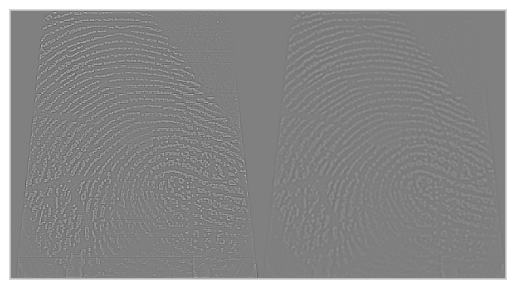

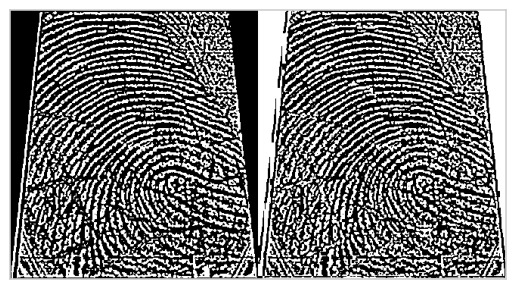

In [18]:
# Edge detection
img_laplace = cv2.Laplacian(img, cv2.CV_64F)
img_blur = cv2.GaussianBlur(img_laplace, (5,5), 0)
ret, img_bin = cv2.threshold(img_blur, 0, 255, 0)
img_bin_custom = binarise(img_blur)
    
display_image(np.hstack((img_laplace, img_blur)))
display_image(np.hstack((img_bin, img_bin_custom)))

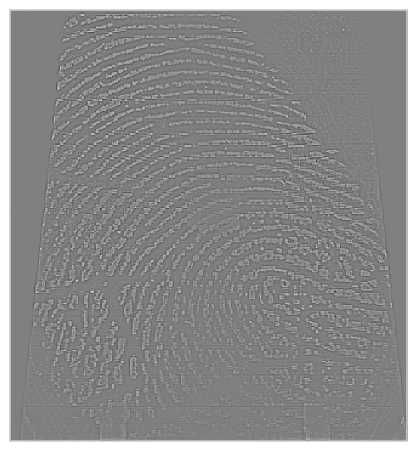

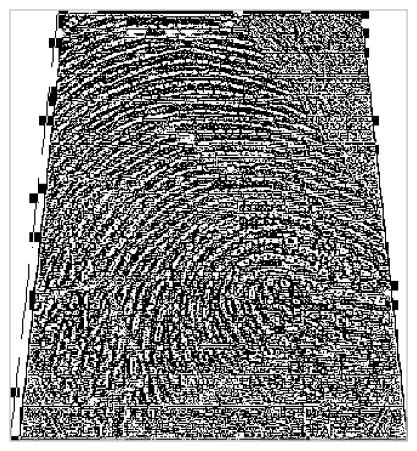

In [19]:
_, bin_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
img_bin_custom = binarise(img_laplace)

display_image(img_laplace)
display_image(img_bin_custom)

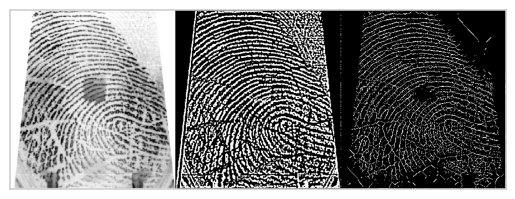

In [20]:
size = np.size(img)
skel = np.zeros(img.shape, np.uint8)

ret, img_base = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
element = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
done = False

while not done:
    eroded = cv2.erode(img_base, element)
    temp = cv2.dilate(eroded, element)
    temp = cv2.subtract(img_base, temp)
    skel = cv2.bitwise_or(skel, temp)
    img_base = eroded.copy()

    zeros = size - cv2.countNonZero(img_base)
    if zeros == size:
        done = True
        
# Smoothing required after binarisation. 
display_image(np.hstack((img, img_bin, skel)))

In [21]:
path_root = f'../Project-Data/train'
all_files = [f'{path_root}/{name}' for name in os.listdir(path_root) if name.endswith('.bmp')]

all_files[:2]

['../Project-Data/train/205_R0_2.bmp', '../Project-Data/train/063_R0_2.bmp']

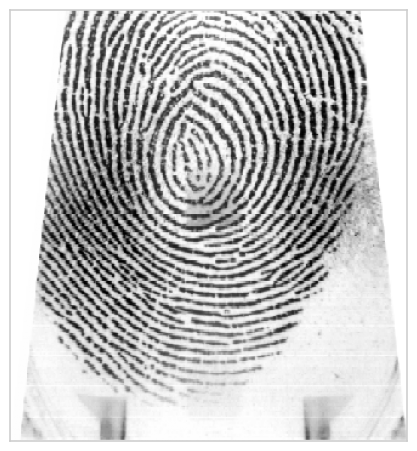

In [22]:
raw_img = load_image(all_files[0], True)
display_image(raw_img)

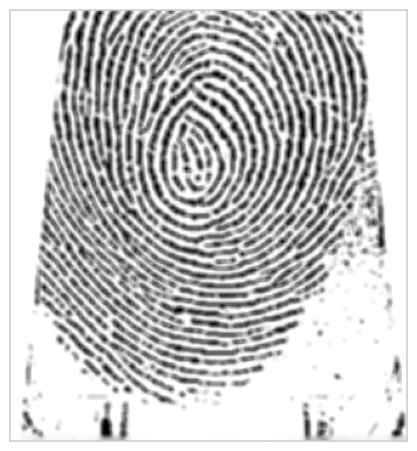

In [23]:
# Gabor filtering (binarise) - edge detection
def build_filters():
    filters = []
    ksize = 5
    for theta in np.arange(0, np.pi, np.pi / 16):
        kern = cv2.getGaborKernel((ksize, ksize), theta=theta, sigma=2.0, 
                                 lambd=15.0, gamma=0.25, psi=0, ktype=cv2.CV_64F)
        # ksize – Size of the filter returned.
        # sigma – Standard deviation of the gaussian envelope.
        # theta – Orientation of the normal to the parallel stripes of a Gabor function.
        # lambd – Wavelength of the sinusoidal factor.
        # gamma – Spatial aspect ratio.
        # psi – Phase offset.
        # ktype – Type of filter coefficients. It can be CV_32F or CV_64F .
        kern /= 1.1 * kern.sum()
        filters.append(kern)
    return filters

def process(img, filters):
    accum = np.zeros_like(img)
    for kern in filters:
        fimg = cv2.filter2D(img, cv2.CV_8UC3, kern)
        np.maximum(accum, fimg, accum)
    
    return accum

img_gb = process(binarise(raw_img), build_filters())
# threshold, img_gb = cv.threshold(img_gb, 0, 255, cv.THRESH_BINARY | cv.THRESH_OTSU)

display_image(img_gb)

In [24]:
def blur(image, size=(5,5), std=0):
    # Standard cv2 parameters, simplified function
    return cv2.GaussianBlur(image, size, std)

def filter_averaging(image):
    kernel = np.ones((5,5), np.float32) / 25
    return cv2.filter2D(image, -1, kernel)

def filter_bilateral(image):
    return cv2.bilateralFilter(image, 9, 75, 75)

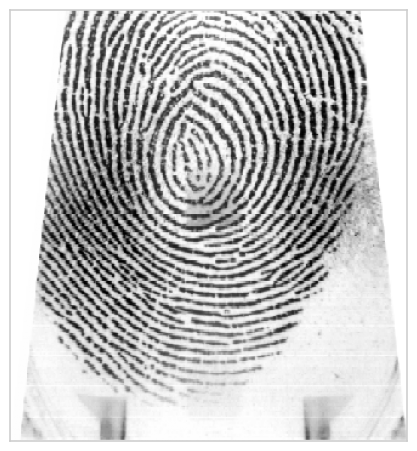

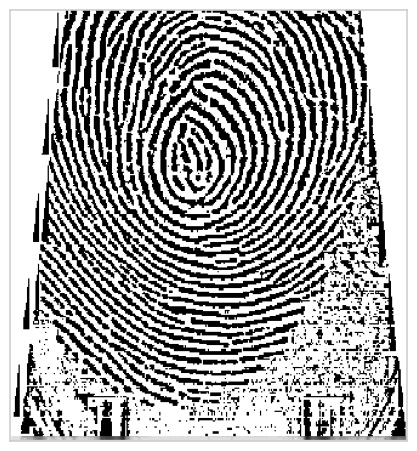

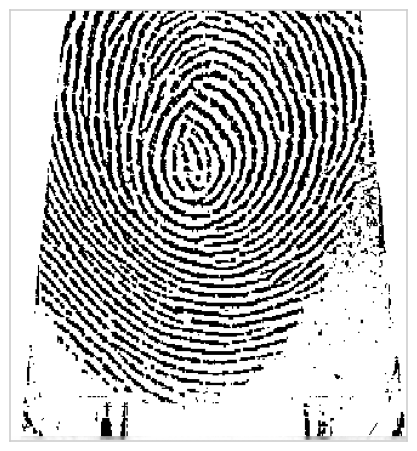

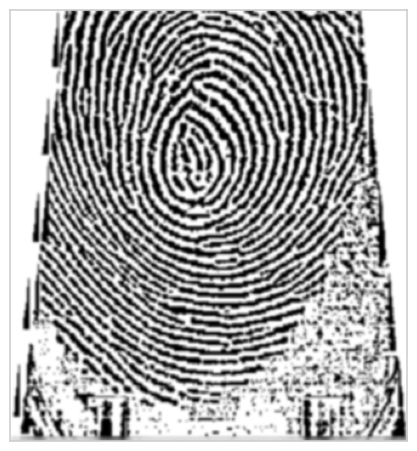

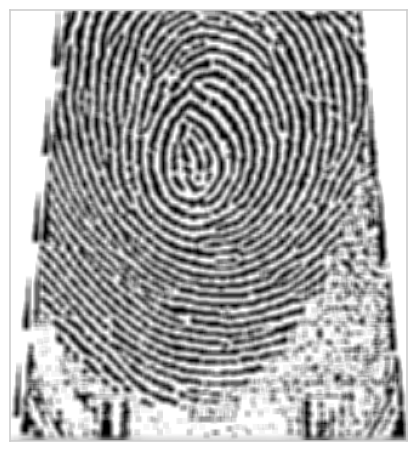

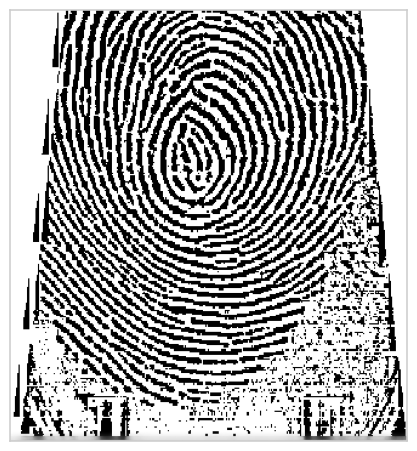

In [25]:
# from medpy.filter.smoothing import anisotropic_diffusion

raw_img_he = histogram_equalisation(raw_img)
raw_img_he_bin = binarise(raw_img_he)
# raw_img_ad = anisotropic_diffusion(raw_img_he_bin)

display_image(raw_img)
display_image(raw_img_he_bin)
display_image(binarise(raw_img))
display_image(blur(raw_img_he_bin))
display_image(filter_averaging(raw_img_he_bin))
display_image(filter_bilateral(raw_img_he_bin))

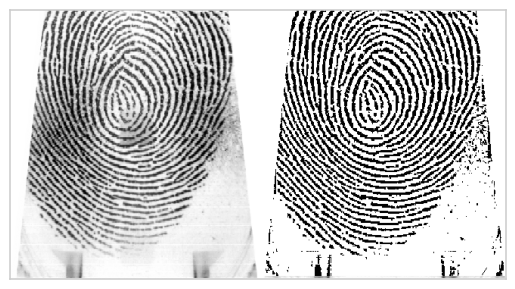

In [26]:
from skimage import exposure

img_bin = binarise(raw_img)
img_adapteq = exposure.equalize_adapthist(img_bin, clip_limit=0.03)
display_image(np.hstack((raw_img, img_adapteq * 255)))

# Image Enhancement

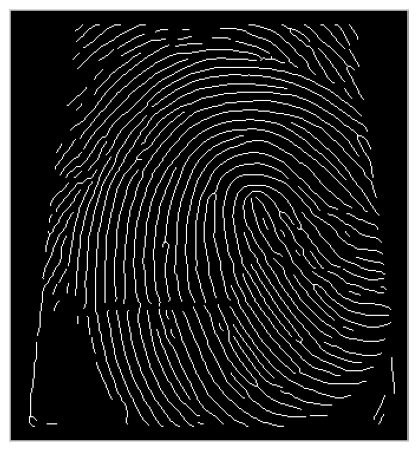

In [27]:
# Revert gray colour levels. Match scale with the raw image for comparison.
path_train = '../Project-Data/train/009_R0_0.bmp'
path_test = '../Project-Data/test/009_R0_4.bmp'

# Image loading
img_train = load_image(path_train, True)
img_test = load_image(path_test, True)
# img = histogram_equalisation(img)

img_enhanced_train = enhance_image(img_train, padding=5)
img_enhanced_test = enhance_image(img_test, padding=5)

display_image(img_enhanced_train)

# Minutiae extraction

In [28]:
# Minutiae libs
from scipy.spatial import distance
from itertools import combinations

from libs.minutiae import *

Base img minutiae: 74 
  - Termination : 70 
  - Bifurcation : 4 
INFO: Plotting terminations' coordinates
INFO: Plotting bifurcations' coordinates


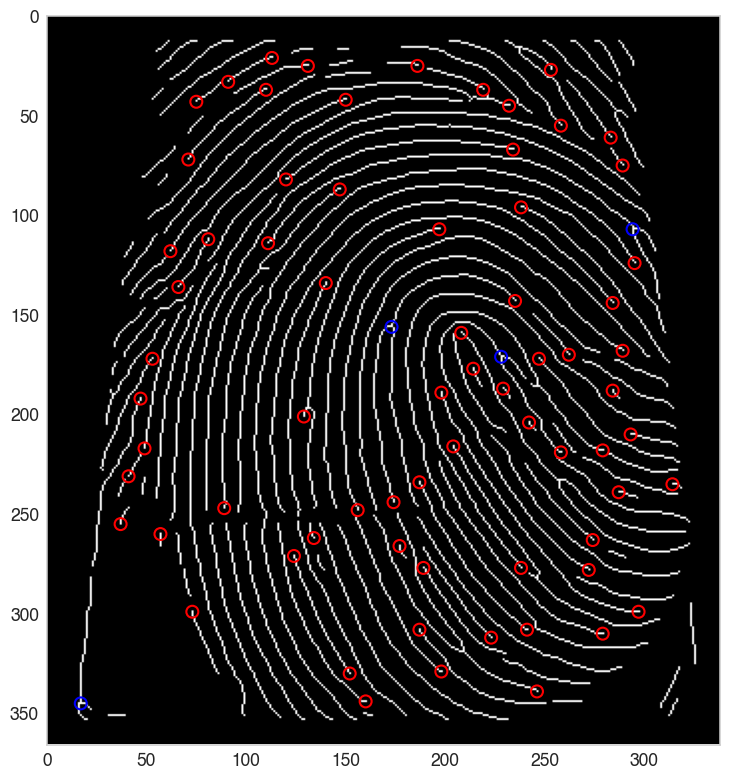

Test img minutiae: 80 
  - Termination : 74 
  - Bifurcation : 6 
INFO: Plotting terminations' coordinates
INFO: Plotting bifurcations' coordinates


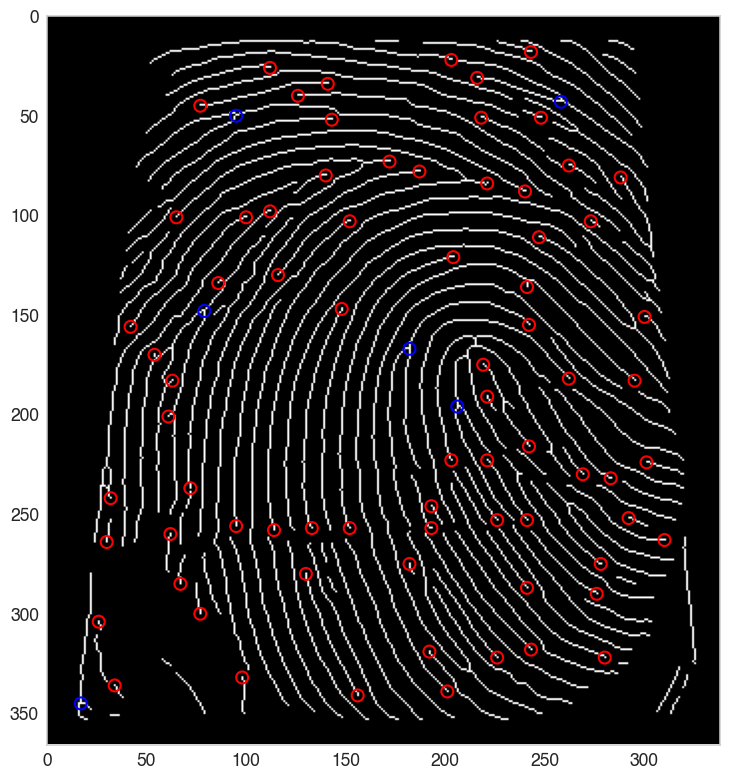

In [29]:

# type: 0=no minutia，1=termination，3=bifurcation

import importlib
import libs.minutiae
importlib.reload(libs.minutiae)
from libs.minutiae import process_minutiae, plot_minutiae


minutiae_base, types_base = process_minutiae(
    img_enhanced_train, 
    min_distance=10,           
    eliminate_false=True,      
    false_min_distance=15,     
    max_neighbors=3,         
    return_types=True          
)

print(f"Base img minutiae: {len(minutiae_base)} ")
print(f"  - Termination : {types_base.count(1)} ")
print(f"  - Bifurcation : {types_base.count(3)} ")

# 按类型分开 minutiae
terminations_base = [m for m, t in zip(minutiae_base, types_base) if t == 1]
bifurcations_base = [m for m, t in zip(minutiae_base, types_base) if t == 3]
plot_minutiae(img_enhanced_train, terminations=terminations_base, bifurcations=bifurcations_base, size=8)


minutiae_test, types_test = process_minutiae(
    img_enhanced_test, 
    min_distance=10,           
    eliminate_false=True,   
    false_min_distance=15,     
    max_neighbors=3,           
    return_types=True        
)
print(f"Test img minutiae: {len(minutiae_test)} ")
print(f"  - Termination : {types_test.count(1)} ")
print(f"  - Bifurcation : {types_test.count(3)} ")


terminations_test = [m for m, t in zip(minutiae_test, types_test) if t == 1]
bifurcations_test = [m for m, t in zip(minutiae_test, types_test) if t == 3]
plot_minutiae(img_enhanced_test, terminations=terminations_test, bifurcations=bifurcations_test, size=8)

Best rotation angle: -2 
in this angle 42 matches
Tuple profile found: 1 matches

 calculating score....
INFO: Score - 1.05
  - Base minutiae : 74
  - Test minutiae: 80
  - Matches count: 42


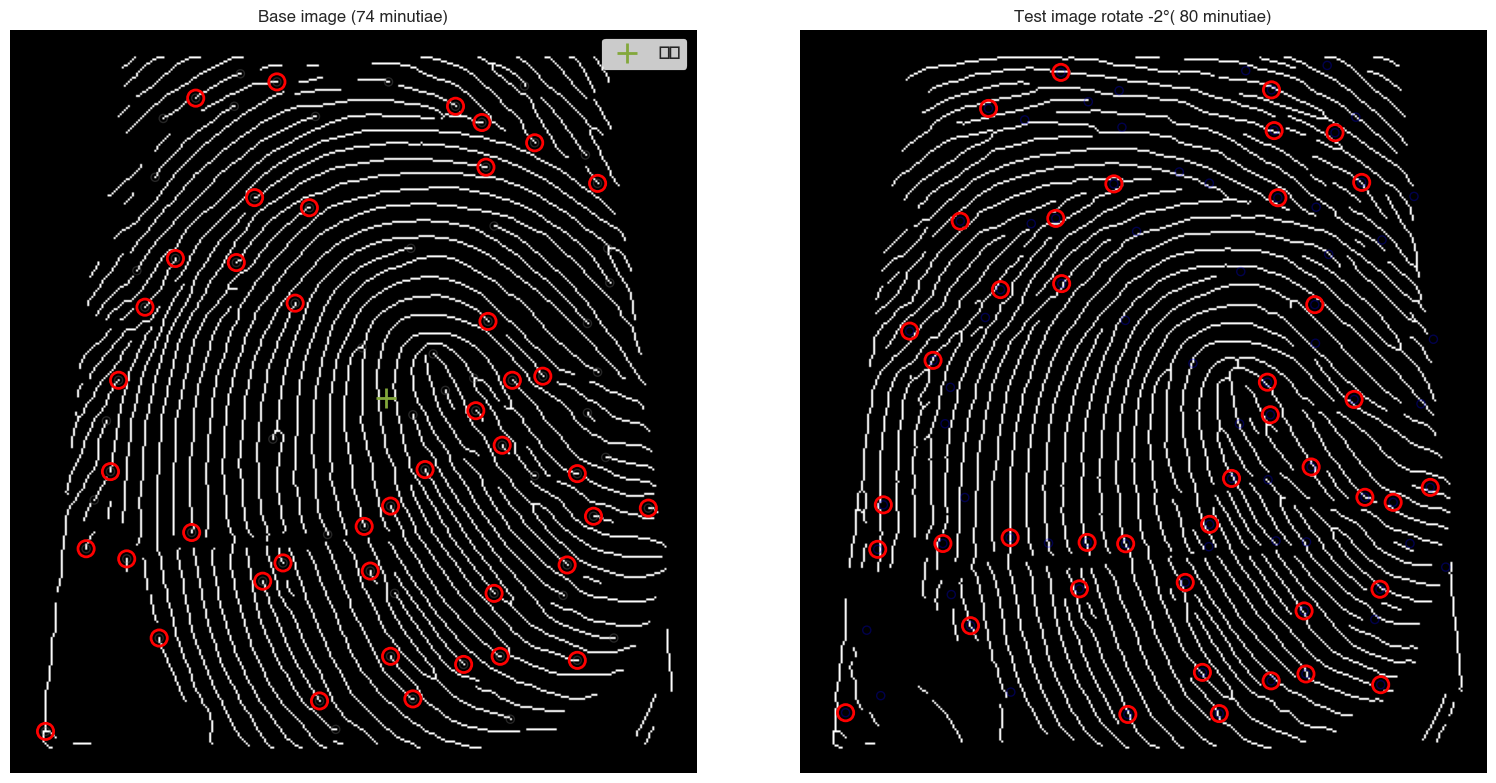


done!


In [30]:

from libs.minutiae import generate_tuple_profile
from libs.matching import match_tuples, evaluate
from libs.basics import euclidian_distance
from libs.enhancing import ridge_orient
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import numpy as np
import math



def compute_centroid(minutiae):
    
    if len(minutiae) == 0:
        return None
    coords = np.array(minutiae)
    centroid = np.mean(coords, axis=0)
    return centroid

def align_by_centroid(minutiae, target_centroid):
    
    if len(minutiae) == 0:
        return minutiae
    current_centroid = compute_centroid(minutiae)
    if current_centroid is None:
        return minutiae
    translation = target_centroid - current_centroid
    aligned = [(y + translation[0], x + translation[1]) for y, x in minutiae]
    return aligned

def rotate_minutiae(minutiae, centroid, angle_deg):
    
    if len(minutiae) == 0 or abs(angle_deg) < 0.1:
        return minutiae
    
    angle_rad = np.deg2rad(angle_deg)
    cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)
    rotation_matrix = np.array([[cos_a, -sin_a], [sin_a, cos_a]])
    
    coords = np.array(minutiae) - centroid
    coords_rotated = coords @ rotation_matrix.T
    rotated = [(y + centroid[0], x + centroid[1]) for y, x in coords_rotated]
    return rotated

centroid_base = compute_centroid(minutiae_base)
centroid_test = compute_centroid(minutiae_test)


minutiae_test_aligned = align_by_centroid(minutiae_test, centroid_base)



def extract_minutiae_orientations(image, minutiae):
    
    orientation = ridge_orient(image, sigma_gradient=1, sigma_block=7, sigma_orientation=7)
    
    orientations = []
    for y, x in minutiae:
        
        y_idx = int(np.clip(y, 0, orientation.shape[0] - 1))
        x_idx = int(np.clip(x, 0, orientation.shape[1] - 1))
        angle_rad = orientation[y_idx, x_idx]
        angle_deg = np.rad2deg(angle_rad) % 180  # 方向是0-180度（因为脊线方向是周期性的）
        orientations.append(angle_deg)
    
    return orientations


orientations_base = extract_minutiae_orientations(img_enhanced_train, minutiae_base)
orientations_test = extract_minutiae_orientations(img_enhanced_test, minutiae_test)


# ========== Hough Transform ==========


def find_best_rotation_with_matching(minutiae1, minutiae2, orientations1, orientations2, 
                                     types1, types2,
                                     angle_range=(-10, 10), angle_step=1, 
                                     distance_threshold=20, orientation_threshold=15):

    if len(minutiae1) < 3 or len(minutiae2) < 3:
        return 0, [], []
    
    best_angle = 0
    best_matches_count = 0
    best_common_base = []
    best_common_test = []
    
    centroid1 = compute_centroid(minutiae1)
    centroid2 = compute_centroid(minutiae2)
    
  
    coords1 = np.array(minutiae1) - centroid1
    

    for angle in range(angle_range[0], angle_range[1] + 1, angle_step):
      
        minutiae2_rotated = rotate_minutiae(minutiae2, centroid2, angle)
        coords2_rotated = np.array(minutiae2_rotated) - centroid2
   
        orientations2_rotated = [(o + angle) % 180 for o in orientations2]
        
      
        distances = cdist(coords1, coords2_rotated)
        
       
        matches_base = []
        matches_test = []
        used2 = set()
        
        for i, m1 in enumerate(minutiae1):
            
            min_dist_idx = np.argmin(distances[i])
            min_dist = distances[i][min_dist_idx]
            
            
            ori1 = orientations1[i]
            ori2_rotated = orientations2_rotated[min_dist_idx]
           
            ori_diff = abs(ori1 - ori2_rotated)
            ori_diff = min(ori_diff, 180 - ori_diff) 
            
        
            type1 = types1[i]
            type2 = types2[min_dist_idx]
            type_match = (type1 == type2)
            
       
            if (min_dist < distance_threshold and 
                ori_diff < orientation_threshold and 
                type_match and  
                min_dist_idx not in used2):
                matches_base.append(m1)
                matches_test.append(minutiae2_rotated[min_dist_idx])
                used2.add(min_dist_idx)
        

        if len(matches_base) > best_matches_count:
            best_matches_count = len(matches_base)
            best_angle = angle
            best_common_base = matches_base
            best_common_test = matches_test
    
    return best_angle, best_common_base, best_common_test


best_angle, common_points_base, common_points_test = find_best_rotation_with_matching(
    minutiae_base, 
    minutiae_test_aligned,
    orientations_base,
    orientations_test,
    types_base,
    types_test,
    angle_range=(-30, 30),  # 旋转角度限制在10度以内
    angle_step=1,
    distance_threshold=20,   # 位置距离阈值（像素）
    orientation_threshold=15  # 方向角度阈值（度）
)

print(f"Best rotation angle: {best_angle} ")
print(f"in this angle {len(common_points_base)} matches")

# 验证匹配点的类型
if len(common_points_base) > 0:

    type_matches = 0
    for i, m_base in enumerate(common_points_base):
        # 找到 base 中的索引
        base_idx = minutiae_base.index(m_base) if m_base in minutiae_base else -1
        # 找到 test 中的索引（在旋转后的列表中）
        test_idx = -1
        for j, m_test in enumerate(minutiae_test_aligned):
            if m_test == common_points_test[i]:
                test_idx = j
                break
        
        if base_idx >= 0 and test_idx >= 0:
            type_base = types_base[base_idx]
            type_test = types_test[test_idx]
            match_status = "✓" if type_base == type_test else "✗"
            if type_base == type_test:
                type_matches += 1


if abs(best_angle) > 0.1:
    centroid_test_aligned = compute_centroid(minutiae_test_aligned)
    minutiae_test_final = rotate_minutiae(minutiae_test_aligned, centroid_test_aligned, best_angle)

else:
    minutiae_test_final = minutiae_test_aligned


# ========== tuple profile  ==========

tuple_profile_base = generate_tuple_profile(minutiae_base)
tuple_profile_test_final = generate_tuple_profile(minutiae_test_final)


common_points_base_tuple, common_points_test_tuple = match_tuples(
    tuple_profile_base, 
    tuple_profile_test_final, 
    th_range=0.01,
    th_angle=1.5
)

print(f"Tuple profile found: {len(common_points_base_tuple)} matches")


all_matches_base = {}
all_matches_test = {}

for b, t in zip(common_points_base, common_points_test):
    all_matches_base[b] = t

for b, t in zip(common_points_base_tuple, common_points_test_tuple):
    if b not in all_matches_base:
        all_matches_base[b] = t

common_points_base = list(all_matches_base.keys())
common_points_test = [all_matches_base[b] for b in common_points_base]


# ========== score  ==========
print("\n calculating score....")

total_minutiae = max(len(minutiae_base), len(minutiae_test_final))
min_minutiae = min(len(minutiae_base), len(minutiae_test_final))
matched_count = len(common_points_base)

# 计算匹配分数
minutiae_score_threshold = total_minutiae / 2
match_result = evaluate(common_points_base, minutiae_base, minutiae_test_final)

match_score_ratio = matched_count / minutiae_score_threshold if minutiae_score_threshold > 0 else 0
match_percentage_min = (matched_count / min_minutiae) * 100 if min_minutiae > 0 else 0
match_percentage_total = (matched_count / total_minutiae) * 100 if total_minutiae > 0 else 0


print(f"  - Base minutiae : {len(minutiae_base)}")
print(f"  - Test minutiae: {len(minutiae_test_final)}")
print(f"  - Matches count: {matched_count}")



# ========== visualization ==========

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 显示 base 图像和匹配点
axes[0].imshow(img_enhanced_train, cmap='gray')
axes[0].set_title(f'Base image ({len(minutiae_base)} minutiae)', fontsize=12)
axes[0].axis('off')


# 标记质心
if centroid_base is not None:
    axes[0].plot(centroid_base[1], centroid_base[0], 'g+', markersize=15, markeredgewidth=2, label='质心')
    axes[0].legend()

# 标记所有 minutiae
for y, x in minutiae_base:
    circle = plt.Circle((x, y), radius=2, linewidth=1, color='gray', fill=False, alpha=0.3)
    axes[0].add_patch(circle)

# 标记匹配的点（红色）
for y, x in common_points_base:
    circle = plt.Circle((x, y), radius=4, linewidth=2, color='red', fill=False)
    axes[0].add_patch(circle)

# 显示 test 图像（对齐+旋转后）
axes[1].imshow(img_enhanced_test, cmap='gray')
axes[1].set_title(f'Test image rotate {best_angle}°( {len(minutiae_test_final)} minutiae)', fontsize=12)
axes[1].axis('off')

# 标记对齐后的 minutiae
for y, x in minutiae_test_final:
    circle = plt.Circle((x, y), radius=2, linewidth=1, color='blue', fill=False, alpha=0.3)
    axes[1].add_patch(circle)

# 标记匹配的点（红色）
for y, x in common_points_test:
    circle = plt.Circle((x, y), radius=4, linewidth=2, color='red', fill=False)
    axes[1].add_patch(circle)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("done!")
print("=" * 60)


In [36]:

import os
import numpy as np
from libs.basics import load_image
from libs.enhancing import enhance_image, ridge_orient
from libs.minutiae import process_minutiae

features_dir = '../features'
os.makedirs(features_dir, exist_ok=True)


def extract_minutiae_orientations(image, minutiae):
 
    orientation = ridge_orient(image, sigma_gradient=1, sigma_block=7, sigma_orientation=7)
    orientations = []
    for y, x in minutiae:
        y_idx = int(np.clip(y, 0, orientation.shape[0] - 1))
        x_idx = int(np.clip(x, 0, orientation.shape[1] - 1))
        angle_rad = orientation[y_idx, x_idx]
        angle_deg = np.rad2deg(angle_rad) % 180  # 0-180度
        orientations.append(angle_deg)
    return orientations

# Enroll 训练集（0-10 用户）
train_path = '../Project-Data/train'
enrolled_users = []

for user_id in range(500):  # 0-10
    print(f"processing user {user_id:03d}...")
    
    user_features = []  
    
    for sample_id in range(3): 
        train_file = f'{train_path}/{user_id:03d}_R0_{sample_id}.bmp'
        
        if os.path.exists(train_file):
            # 加载和增强图像
            img = load_image(train_file, True)
            if img is not None:
                img_enhanced = enhance_image(img, padding=5)
                
                # 提取 minutiae 和类型
                minutiae, types = process_minutiae(img_enhanced, return_types=True, 
                                                   eliminate_false=True, 
                                                   false_min_distance=15, 
                                                   max_neighbors=3)
                
                if len(minutiae) > 0:
                  
                    orientations = extract_minutiae_orientations(img_enhanced, minutiae)
                    
             
                    features = []
                    for i, (y, x) in enumerate(minutiae):
                        features.append([x, y, orientations[i], types[i]])
                    
                    feature_array = np.array(features, dtype=np.float32)
                    user_features.append(feature_array)
                    
                    print(f"  sample {sample_id}: {len(minutiae)} minutiae")
                else:
                    print(f"  sample {sample_id}: no minutiae")
            else:
                print(f"  sample {sample_id}: no imgae")
        else:
            print(f"  sample {sample_id}: no file")
    
    if len(user_features) > 0:

        user_features_array = np.array(user_features, dtype=object)
        save_path = f'{features_dir}/user_{user_id:03d}_features.npy'
        np.save(save_path, user_features_array, allow_pickle=True)
        enrolled_users.append(user_id)
        
        # 显示保存的信息
        total_minutiae = sum(len(f) for f in user_features)
        print(f"  ✓ saved in: {save_path}")
        print(f"  ✓ {len(user_features)} samples,  {total_minutiae}  minutiae")
    else:
        print(f"  ✗ user {user_id:03d} has no features")

print(f"\n{'='*80}")
print(f"Enrollment finished！")
print(f"  - enrolled_users: {len(enrolled_users)}")

print("=" * 80)

processing user 000...
  sample 0: 85 minutiae
  sample 1: 100 minutiae
  sample 2: 99 minutiae
  ✓ saved in: ../features/user_000_features.npy
  ✓ 3 samples,  284  minutiae
processing user 001...
  sample 0: 42 minutiae
  sample 1: 47 minutiae
  sample 2: 62 minutiae
  ✓ saved in: ../features/user_001_features.npy
  ✓ 3 samples,  151  minutiae
processing user 002...
  sample 0: 85 minutiae
  sample 1: 56 minutiae
  sample 2: 75 minutiae
  ✓ saved in: ../features/user_002_features.npy
  ✓ 3 samples,  216  minutiae
processing user 003...
  sample 0: 92 minutiae
  sample 1: 85 minutiae
  sample 2: 98 minutiae
  ✓ saved in: ../features/user_003_features.npy
  ✓ 3 samples,  275  minutiae
processing user 004...
  sample 0: 51 minutiae
  sample 1: 38 minutiae
  sample 2: 39 minutiae
  ✓ saved in: ../features/user_004_features.npy
  ✓ 3 samples,  128  minutiae
processing user 005...
  sample 0: 47 minutiae
  sample 1: 79 minutiae
  sample 2: 54 minutiae
  ✓ saved in: ../features/user_005_feat

In [42]:
# 基于EER的指纹匹配评估：计算EER确定最优threshold，然后进行评估
import os
import numpy as np
from libs.basics import load_image
from libs.enhancing import enhance_image, ridge_orient
from libs.minutiae import process_minutiae
from scipy.spatial.distance import cdist

print("=" * 80)
print("基于EER的指纹匹配评估")
print("=" * 80)

# 配置参数
features_dir = '../features'
validate_path = '../Project-Data/validate'

def extract_minutiae_orientations(image, minutiae):
    """提取 minutiae 的方向"""
    orientation = ridge_orient(image, sigma_gradient=1, sigma_block=7, sigma_orientation=7)
    orientations = []
    for y, x in minutiae:
        y_idx = int(np.clip(y, 0, orientation.shape[0] - 1))
        x_idx = int(np.clip(x, 0, orientation.shape[1] - 1))
        angle_rad = orientation[y_idx, x_idx]
        angle_deg = np.rad2deg(angle_rad) % 180  # 0-180度
        orientations.append(angle_deg)
    return orientations

def compute_centroid_from_features(features):
    """计算特征的质心"""
    if len(features) == 0:
        return None
    coords = features[:, :2]  # x, y 坐标
    centroid = np.mean(coords, axis=0)
    return centroid

def align_features_by_centroid(features, target_centroid):
    """通过质心对齐特征"""
    if len(features) == 0:
        return features
    current_centroid = compute_centroid_from_features(features)
    if current_centroid is None:
        return features
    translation = target_centroid - current_centroid
    aligned_features = features.copy()
    aligned_features[:, 0] += translation[0]  # x
    aligned_features[:, 1] += translation[1]  # y
    return aligned_features

def rotate_features(features, centroid, angle_deg):
    """旋转特征"""
    if len(features) == 0 or abs(angle_deg) < 0.1:
        return features
    angle_rad = np.deg2rad(angle_deg)
    cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)
    rotation_matrix = np.array([[cos_a, -sin_a], [sin_a, cos_a]])
    
    coords = features[:, :2] - centroid
    coords_rotated = coords @ rotation_matrix.T
    rotated_features = features.copy()
    rotated_features[:, 0] = coords_rotated[:, 0] + centroid[0]
    rotated_features[:, 1] = coords_rotated[:, 1] + centroid[1]
    # 旋转方向
    rotated_features[:, 2] = (rotated_features[:, 2] + angle_deg) % 180
    return rotated_features

def match_features(train_features, validate_features, 
                   angle_range=(-10, 10), angle_step=1,
                   distance_threshold=20, orientation_threshold=15):
    """匹配两个特征集，返回最佳匹配分数"""
    if len(train_features) == 0 or len(validate_features) == 0:
        return 0, 0, 0.0
    
    best_angle = 0
    best_matches_count = 0
    
    # 提取位置、方向、类型
    train_pos = train_features[:, :2]  # x, y
    train_ori = train_features[:, 2]  # orientation
    train_type = train_features[:, 3]  # type
    
    validate_pos = validate_features[:, :2]
    validate_ori = validate_features[:, 2]
    validate_type = validate_features[:, 3]
    
    centroid_train = compute_centroid_from_features(train_features)
    centroid_validate = compute_centroid_from_features(validate_features)
    
    # 对齐到训练特征的质心
    validate_aligned = align_features_by_centroid(validate_features, centroid_train)
    
    coords_train = train_pos - centroid_train
    
    # 尝试不同的旋转角度
    for angle in range(angle_range[0], angle_range[1] + 1, angle_step):
        validate_rotated = rotate_features(validate_aligned, centroid_train, angle)
        validate_pos_rotated = validate_rotated[:, :2]
        validate_ori_rotated = validate_rotated[:, 2]
        
        coords_validate = validate_pos_rotated - centroid_train
        
        # 计算距离矩阵
        distances = cdist(coords_train, coords_validate)
        
        matches_count = 0
        used_validate = set()
        
        for i in range(len(train_features)):
            min_dist_idx = np.argmin(distances[i])
            min_dist = distances[i][min_dist_idx]
            
            # 检查方向差异
            ori_diff = abs(train_ori[i] - validate_ori_rotated[min_dist_idx])
            ori_diff = min(ori_diff, 180 - ori_diff)  # 处理周期性
            
            # 检查类型匹配
            type_match = (train_type[i] == validate_type[min_dist_idx])
            
            # 多约束匹配：位置、方向、类型
            if (min_dist < distance_threshold and 
                ori_diff < orientation_threshold and 
                type_match and
                min_dist_idx not in used_validate):
                matches_count += 1
                used_validate.add(min_dist_idx)
        
        if matches_count > best_matches_count:
            best_matches_count = matches_count
            best_angle = angle
    
    # 计算匹配分数
    total_minutiae = max(len(train_features), len(validate_features))
    match_score = best_matches_count / (total_minutiae / 2) if total_minutiae > 0 else 0.0
    
    return best_angle, best_matches_count, match_score

# 加载所有已注册的特征
print("\n加载已注册的特征...")
enrolled_features = {}
feature_files = [f for f in os.listdir(features_dir) if f.endswith('_features.npy')]
for feature_file in feature_files:
    try:
        user_id = int(feature_file.replace('user_', '').replace('_features.npy', ''))
        features = np.load(os.path.join(features_dir, feature_file), allow_pickle=True)
        enrolled_features[user_id] = features
    except:
        continue

print(f"已加载 {len(enrolled_features)} 个用户的特征")

# 第一步：收集所有验证样本的特征
print("\n" + "=" * 80)
print("第一步：提取验证样本特征...")
print("=" * 80)

validate_features_dict = {}  # {user_id: features_array}

for validate_user_id in range(500):
    # 加载验证样本
    validate_file = f'{validate_path}/{validate_user_id:03d}_R0_4.bmp'
    if not os.path.exists(validate_file):
        # 尝试 test 目录
        validate_file = f'../Project-Data/test/{validate_user_id:03d}_R0_4.bmp'
    
    if not os.path.exists(validate_file):
        if (validate_user_id + 1) % 50 == 0:
            print(f"  处理中: 用户 {validate_user_id:03d} (文件不存在), 已收集: {len(validate_features_dict)} 个")
        continue
    
    img_validate = load_image(validate_file, True)
    if img_validate is None:
        if (validate_user_id + 1) % 50 == 0:
            print(f"  处理中: 用户 {validate_user_id:03d} (无法加载图像), 已收集: {len(validate_features_dict)} 个")
        continue
    
    # 提取验证样本的特征
    img_validate_enhanced = enhance_image(img_validate, padding=5)
    minutiae_validate, types_validate = process_minutiae(
        img_validate_enhanced, 
        return_types=True,
        eliminate_false=True, 
        false_min_distance=15, 
        max_neighbors=3
    )
    
    if len(minutiae_validate) == 0:
        if (validate_user_id + 1) % 50 == 0:
            print(f"  处理中: 用户 {validate_user_id:03d} (未提取到minutiae), 已收集: {len(validate_features_dict)} 个")
        continue
    
    orientations_validate = extract_minutiae_orientations(img_validate_enhanced, minutiae_validate)
    
    # 构建验证特征数组 [x, y, orientation, type]
    validate_features = []
    for i, (y, x) in enumerate(minutiae_validate):
        validate_features.append([x, y, orientations_validate[i], types_validate[i]])
    validate_features = np.array(validate_features, dtype=np.float32)
    
    validate_features_dict[validate_user_id] = validate_features
    
    # 打印进度
    print(f"  ✓ 已收集: 用户 {validate_user_id:03d} ({len(validate_features)} 个minutiae), 总计: {len(validate_features_dict)} 个")

print(f"\n成功提取 {len(validate_features_dict)} 个验证样本的特征")

# 第二步：构建匹配对并收集所有分数（不设置threshold）
print("\n" + "=" * 80)
print("第二步：构建匹配对并收集分数...")
print("=" * 80)

# 存储所有匹配对的分数（不判断是否匹配）
genuine_scores = []  # 真实匹配对的分数
impostor_scores = []  # 错误匹配对的分数

for validate_user_id, validate_features in validate_features_dict.items():
    # 构建真实匹配对：验证指纹 vs 同一用户的所有模板
    if validate_user_id in enrolled_features:
        for template_features in enrolled_features[validate_user_id]:
            angle, matched_count, score = match_features(
                template_features, validate_features,
                angle_range=(-10, 10),
                distance_threshold=20,
                orientation_threshold=15
            )
            genuine_scores.append(score)
    
    # 构建错误匹配对：验证指纹 vs 其他用户的模板
    for template_user_id, template_features_list in enrolled_features.items():
        if template_user_id == validate_user_id:
            continue  # 跳过同一用户
        
        # 对每个模板进行匹配
        for template_features in template_features_list:
            angle, matched_count, score = match_features(
                template_features, validate_features,
                angle_range=(-10, 10),
                distance_threshold=20,
                orientation_threshold=15
            )
            impostor_scores.append(score)
    
    if len(validate_features_dict) > 0 and (validate_user_id + 1) % 50 == 0:
        print(f"  已处理 {validate_user_id + 1}/{len(validate_features_dict)} 个验证样本...")

genuine_scores = np.array(genuine_scores)
impostor_scores = np.array(impostor_scores)

print(f"\n收集完成:")
print(f"  真实匹配对 (genuine pairs): {len(genuine_scores)}")
print(f"  错误匹配对 (impostor pairs): {len(impostor_scores)}")
print(f"  真实匹配分数范围: [{np.min(genuine_scores):.3f}, {np.max(genuine_scores):.3f}], 平均: {np.mean(genuine_scores):.3f}")
print(f"  错误匹配分数范围: [{np.min(impostor_scores):.3f}, {np.max(impostor_scores):.3f}], 平均: {np.mean(impostor_scores):.3f}")

# 第三步：计算EER并确定最优threshold
print("\n" + "=" * 80)
print("第三步：计算EER (Equal Error Rate)...")
print("=" * 80)

# 生成threshold候选值
all_scores = np.concatenate([genuine_scores, impostor_scores])
min_score = np.min(all_scores)
max_score = np.max(all_scores)
thresholds = np.linspace(min_score, max_score, 1000)

# 计算每个threshold下的FAR和FRR
FARs = []  # False Acceptance Rate
FRRs = []  # False Rejection Rate

for threshold in thresholds:
    # FAR: 错误匹配对中，分数 >= threshold 的比例
    FP = np.sum(impostor_scores >= threshold)
    FAR = (FP / len(impostor_scores) * 100) if len(impostor_scores) > 0 else 0.0
    FARs.append(FAR)
    
    # FRR: 真实匹配对中，分数 < threshold 的比例
    FN = np.sum(genuine_scores < threshold)
    FRR = (FN / len(genuine_scores) * 100) if len(genuine_scores) > 0 else 0.0
    FRRs.append(FRR)

FARs = np.array(FARs)
FRRs = np.array(FRRs)

# 找到EER点（FAR和FRR最接近的点）
diff = np.abs(FARs - FRRs)
eer_idx = np.argmin(diff)
eer_threshold = thresholds[eer_idx]
eer_value = (FARs[eer_idx] + FRRs[eer_idx]) / 2

print(f"\nEER (Equal Error Rate) 结果:")
print(f"  最优阈值 (threshold): {eer_threshold:.4f}")
print(f"  EER值: {eer_value:.2f}%")
print(f"  此时 FAR: {FARs[eer_idx]:.2f}%")
print(f"  此时 FRR: {FRRs[eer_idx]:.2f}%")

# 使用EER threshold进行最终评估
score_threshold = eer_threshold
print(f"\n使用EER确定的阈值 {score_threshold:.4f} 进行最终评估...")

# 第四步：使用EER threshold计算最终评估指标
print("\n" + "=" * 80)
print("第四步：使用EER threshold计算最终评估指标")
print("=" * 80)

# 使用EER threshold判断匹配
genuine_matches = (genuine_scores >= score_threshold)
impostor_matches = (impostor_scores >= score_threshold)

# 计算混淆矩阵
TP = np.sum(genuine_matches)  # True Positive: 真实匹配且通过阈值
FN = np.sum(~genuine_matches)  # False Negative: 真实匹配但未通过阈值
FP = np.sum(impostor_matches)  # False Positive: 错误匹配但通过阈值
TN = np.sum(~impostor_matches)  # True Negative: 错误匹配且未通过阈值

print(f"\n混淆矩阵:")
print(f"  True Positive (TP):  {TP:6d} - 真实匹配且通过阈值（正确接受）")
print(f"  False Negative (FN): {FN:6d} - 真实匹配但未通过阈值（错误拒绝）")
print(f"  False Positive (FP): {FP:6d} - 错误匹配但通过阈值（错误接受）")
print(f"  True Negative (TN): {TN:6d} - 错误匹配且未通过阈值（正确拒绝）")
print(f"  总计: {TP + FN + FP + TN}")

# 计算各种指标
total_genuine = len(genuine_scores)  # 真实匹配对总数
total_impostor = len(impostor_scores)  # 错误匹配对总数

IMR = (TP / total_genuine * 100) if total_genuine > 0 else 0.0  # Identity Match Rate (正确匹配率)
FAR = (FP / total_impostor * 100) if total_impostor > 0 else 0.0  # False Acceptance Rate (错误接受率)
FRR = (FN / total_genuine * 100) if total_genuine > 0 else 0.0  # False Rejection Rate (错误拒绝率)
TAR = IMR  # True Acceptance Rate (正确接受率)
TRR = (TN / total_impostor * 100) if total_impostor > 0 else 0.0  # True Rejection Rate (正确拒绝率)

# 准确率
accuracy = ((TP + TN) / (TP + TN + FP + FN) * 100) if (TP + TN + FP + FN) > 0 else 0.0

# 精确率和召回率
precision = (TP / (TP + FP) * 100) if (TP + FP) > 0 else 0.0
recall = (TP / (TP + FN) * 100) if (TP + FN) > 0 else 0.0
f1_score = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

print(f"\n性能指标 (使用EER阈值 = {score_threshold:.4f}):")
print(f"  EER (Equal Error Rate):          {eer_value:.2f}% - 等错误率")
print(f"  IMR (Identity Match Rate / TAR): {IMR:.2f}% - 正确匹配率")
print(f"  FAR (False Acceptance Rate):     {FAR:.2f}% - 错误接受率")
print(f"  FRR (False Rejection Rate):      {FRR:.2f}% - 错误拒绝率")
print(f"  TRR (True Rejection Rate):       {TRR:.2f}% - 正确拒绝率")
print(f"  Accuracy (准确率):               {accuracy:.2f}%")
print(f"  Precision (精确率):              {precision:.2f}%")
print(f"  Recall (召回率):                 {recall:.2f}%")
print(f"  F1-Score:                        {f1_score:.2f}%")

print(f"\n统计信息:")
print(f"  真实匹配对总数 (Genuine Pairs): {total_genuine}")
print(f"  错误匹配对总数 (Impostor Pairs): {total_impostor}")
print(f"  总匹配对数: {total_genuine + total_impostor}")

print(f"\n分数分布统计:")
print(f"  真实匹配对:")
print(f"    平均分数: {np.mean(genuine_scores):.3f}")
print(f"    最高分数: {np.max(genuine_scores):.3f}")
print(f"    最低分数: {np.min(genuine_scores):.3f}")
print(f"    标准差: {np.std(genuine_scores):.3f}")
print(f"  错误匹配对:")
print(f"    平均分数: {np.mean(impostor_scores):.3f}")
print(f"    最高分数: {np.max(impostor_scores):.3f}")
print(f"    最低分数: {np.min(impostor_scores):.3f}")
print(f"    标准差: {np.std(impostor_scores):.3f}")

print("=" * 80)


基于EER的指纹匹配评估

加载已注册的特征...
已加载 488 个用户的特征

第一步：提取验证样本特征...
  ✓ 已收集: 用户 000 (82 个minutiae), 总计: 1 个
  ✓ 已收集: 用户 001 (32 个minutiae), 总计: 2 个
  ✓ 已收集: 用户 002 (65 个minutiae), 总计: 3 个
  ✓ 已收集: 用户 003 (78 个minutiae), 总计: 4 个
  ✓ 已收集: 用户 004 (50 个minutiae), 总计: 5 个
  ✓ 已收集: 用户 005 (105 个minutiae), 总计: 6 个
  ✓ 已收集: 用户 006 (60 个minutiae), 总计: 7 个
  ✓ 已收集: 用户 007 (49 个minutiae), 总计: 8 个
  ✓ 已收集: 用户 008 (59 个minutiae), 总计: 9 个
  ✓ 已收集: 用户 009 (80 个minutiae), 总计: 10 个
  ✓ 已收集: 用户 010 (44 个minutiae), 总计: 11 个
  ✓ 已收集: 用户 011 (62 个minutiae), 总计: 12 个
  ✓ 已收集: 用户 012 (93 个minutiae), 总计: 13 个
  ✓ 已收集: 用户 013 (71 个minutiae), 总计: 14 个
  ✓ 已收集: 用户 014 (49 个minutiae), 总计: 15 个
  ✓ 已收集: 用户 015 (73 个minutiae), 总计: 16 个
  ✓ 已收集: 用户 016 (60 个minutiae), 总计: 17 个
  ✓ 已收集: 用户 017 (60 个minutiae), 总计: 18 个
  ✓ 已收集: 用户 018 (48 个minutiae), 总计: 19 个
  ✓ 已收集: 用户 019 (86 个minutiae), 总计: 20 个
  ✓ 已收集: 用户 020 (76 个minutiae), 总计: 21 个
  ✓ 已收集: 用户 021 (29 个minutiae), 总计: 22 个
  ✓ 已收集: 用户 022 (60 个minutiae), 总计: 23 个
  ✓ 已收集

In [37]:

import os
import numpy as np
from libs.basics import load_image
from libs.enhancing import enhance_image, ridge_orient
from libs.minutiae import process_minutiae
from scipy.spatial.distance import cdist

print("=" * 80)
print("Matching")
print("=" * 80)


features_dir = '../features'
validate_path = '../Project-Data/validate'

def extract_minutiae_orientations(image, minutiae):

    orientation = ridge_orient(image, sigma_gradient=1, sigma_block=7, sigma_orientation=7)
    orientations = []
    for y, x in minutiae:
        y_idx = int(np.clip(y, 0, orientation.shape[0] - 1))
        x_idx = int(np.clip(x, 0, orientation.shape[1] - 1))
        angle_rad = orientation[y_idx, x_idx]
        angle_deg = np.rad2deg(angle_rad) % 180
        orientations.append(angle_deg)
    return orientations

def compute_centroid_from_features(features):

    if len(features) == 0:
        return None
    coords = features[:, :2]  # x, y 坐标
    centroid = np.mean(coords, axis=0)
    return centroid

def align_features_by_centroid(features, target_centroid):

    if len(features) == 0:
        return features
    current_centroid = compute_centroid_from_features(features)
    if current_centroid is None:
        return features
    translation = target_centroid - current_centroid
    aligned_features = features.copy()
    aligned_features[:, 0] += translation[0]  # x
    aligned_features[:, 1] += translation[1]  # y
    return aligned_features

def rotate_features(features, centroid, angle_deg):

    if len(features) == 0 or abs(angle_deg) < 0.1:
        return features
    angle_rad = np.deg2rad(angle_deg)
    cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)
    rotation_matrix = np.array([[cos_a, -sin_a], [sin_a, cos_a]])
    
    coords = features[:, :2] - centroid
    coords_rotated = coords @ rotation_matrix.T
    rotated_features = features.copy()
    rotated_features[:, 0] = coords_rotated[:, 0] + centroid[0]
    rotated_features[:, 1] = coords_rotated[:, 1] + centroid[1]
    # 旋转方向
    rotated_features[:, 2] = (rotated_features[:, 2] + angle_deg) % 180
    return rotated_features

def match_features(train_features, validate_features, 
                   angle_range=(-10, 10), angle_step=1,
                   distance_threshold=20, orientation_threshold=15):
   
    if len(train_features) == 0 or len(validate_features) == 0:
        return 0, 0, 0.0
    
    best_angle = 0
    best_matches_count = 0
    
    # 提取位置、方向、类型
    train_pos = train_features[:, :2]  # x, y
    train_ori = train_features[:, 2]  # orientation
    train_type = train_features[:, 3]  # type
    
    validate_pos = validate_features[:, :2]
    validate_ori = validate_features[:, 2]
    validate_type = validate_features[:, 3]
    
    centroid_train = compute_centroid_from_features(train_features)
    centroid_validate = compute_centroid_from_features(validate_features)
    

    validate_aligned = align_features_by_centroid(validate_features, centroid_train)
    validate_pos_aligned = validate_aligned[:, :2]
    validate_ori_aligned = validate_aligned[:, 2]
    
    coords_train = train_pos - centroid_train
    
    for angle in range(angle_range[0], angle_range[1] + 1, angle_step):

        validate_rotated = rotate_features(validate_aligned, centroid_train, angle)
        validate_pos_rotated = validate_rotated[:, :2]
        validate_ori_rotated = validate_rotated[:, 2]
        
        coords_validate = validate_pos_rotated - centroid_train
        

        distances = cdist(coords_train, coords_validate)
        
        matches_count = 0
        used_validate = set()
        
        for i in range(len(train_features)):
            min_dist_idx = np.argmin(distances[i])
            min_dist = distances[i][min_dist_idx]
            
       
            ori_diff = abs(train_ori[i] - validate_ori_rotated[min_dist_idx])
            ori_diff = min(ori_diff, 180 - ori_diff)
            
 
            type_match = (train_type[i] == validate_type[min_dist_idx])
            
 
            if (min_dist < distance_threshold and 
                ori_diff < orientation_threshold and 
                type_match and
                min_dist_idx not in used_validate):
                matches_count += 1
                used_validate.add(min_dist_idx)
        
        if matches_count > best_matches_count:
            best_matches_count = matches_count
            best_angle = angle
    

    total_minutiae = max(len(train_features), len(validate_features))
    match_score = best_matches_count / (total_minutiae / 2) if total_minutiae > 0 else 0.0
    
    return best_angle, best_matches_count, match_score


print("\nloading enrolled features...")
enrolled_features = {}
for user_id in range(11):  # 0-10
    feature_file = f'{features_dir}/user_{user_id:03d}_features.npy'
    if os.path.exists(feature_file):
        features = np.load(feature_file, allow_pickle=True)
        enrolled_features[user_id] = features
       

print(f"\n loaded features from {len(enrolled_features)} users ")


print("\n" + "=" * 80)
print("matcing...")
print("=" * 80)

results = []

for user_id in range(500):  # 0-10
    print(f"\n processing sample from{user_id:03d} ...")
    
    # 加载验证样本
    validate_file = f'{validate_path}/{user_id:03d}_R0_4.bmp'
    if not os.path.exists(validate_file):
        validate_file = f'../Project-Data/test/{user_id:03d}_R0_4.bmp'
    
    if not os.path.exists(validate_file):
        print(f"  ✗ no sample")
        continue
    
    img_validate = load_image(validate_file, True)
    if img_validate is None:
        print(f"  ✗ no image")
        continue
    
    # 提取验证样本的特征
    img_validate_enhanced = enhance_image(img_validate, padding=5)
    minutiae_validate, types_validate = process_minutiae(img_validate_enhanced, return_types=True,
                                                         eliminate_false=True,
                                                         false_min_distance=15,
                                                         max_neighbors=3)
    
    if len(minutiae_validate) == 0:
        print(f"  ✗ no minutiae")
        continue
    
    orientations_validate = extract_minutiae_orientations(img_validate_enhanced, minutiae_validate)
    
    # 构建验证特征数组 [x, y, orientation, type]
    validate_features = []
    for i, (y, x) in enumerate(minutiae_validate):
        validate_features.append([x, y, orientations_validate[i], types_validate[i]])
    validate_features = np.array(validate_features, dtype=np.float32)
    
    print(f"  test sample: {len(validate_features)} minutiae")
    
    # 与所有已注册用户进行匹配
    best_match_user = -1
    best_match_score = 0.0
    best_match_angle = 0
    best_match_count = 0
    all_scores = []
    
    for enrolled_user_id, train_features_list in enrolled_features.items():
        # 对每个训练样本进行匹配，取最高分
        user_best_score = 0.0
        user_best_angle = 0
        user_best_count = 0
        
        for train_features in train_features_list:
            angle, matched_count, score = match_features(
                train_features, validate_features,
                angle_range=(-10, 10),
                distance_threshold=20,
                orientation_threshold=15
            )
            
            if score > user_best_score:
                user_best_score = score
                user_best_angle = angle
                user_best_count = matched_count
        
        all_scores.append((enrolled_user_id, user_best_score))
        
        if user_best_score > best_match_score:
            best_match_score = user_best_score
            best_match_user = enrolled_user_id
            best_match_angle = user_best_angle
            best_match_count = user_best_count
    
    # 判断识别是否正确
    is_correct = (best_match_user == user_id)
    
    results.append({
        'true_user': user_id,
        'predicted_user': best_match_user,
        'match_score': best_match_score,
        'match_count': best_match_count,
        'match_angle': best_match_angle,
        'is_correct': is_correct,
        'all_scores': sorted(all_scores, key=lambda x: x[1], reverse=True)[:3]  # 前3名
    })
    
    status = "✓ correct" if is_correct else "✗ incorrect"
    print(f"  results: user {best_match_user:03d} (real match: {user_id:03d}) {status}")
    print(f"  score: {best_match_score:.3f}, matched count: {best_match_count}, angle: {best_match_angle}°")

# 计算准确率
print(f"\n{'='*80}")
print("summary")
print("=" * 80)
print(f"{'ID':<8} {'real user':<10} {'recognitized user':<10} {'score':<12} {'matches':<10} {'angle':<8} {'results':<8}")
print("-" * 80)

correct_count = 0
for r in results:
    status = "✓ correct" if r['is_correct'] else "✗ incorrect"
    if r['is_correct']:
        correct_count += 1
    print(f"{r['true_user']:03d}     {r['true_user']:03d}        {r['predicted_user']:03d}        "
          f"{r['match_score']:<12.3f} {r['match_count']:<10} {r['match_angle']:<8.1f} {status:<8}")

print("-" * 80)
accuracy = (correct_count / len(results)) * 100 if len(results) > 0 else 0.0
print(f"symmary: {len(results)} samples")
print(f"correct: {correct_count} ")
print(f"incorrect: {len(results) - correct_count} ")
print(f"accuracy: {accuracy:.2f}%")
print("=" * 80)

Matching

loading enrolled features...

 loaded features from 11 users 

matcing...

 processing sample from000 ...
  test sample: 82 minutiae
  results: user 003 (real match: 000) ✗ incorrect
  score: 0.847, matched count: 36, angle: 6°

 processing sample from001 ...
  test sample: 32 minutiae
  results: user 005 (real match: 001) ✗ incorrect
  score: 0.596, matched count: 14, angle: 2°

 processing sample from002 ...
  test sample: 65 minutiae
  results: user 002 (real match: 002) ✓ correct
  score: 0.612, matched count: 26, angle: -5°

 processing sample from003 ...
  test sample: 78 minutiae
  results: user 003 (real match: 003) ✓ correct
  score: 1.106, matched count: 47, angle: -1°

 processing sample from004 ...
  test sample: 50 minutiae
  results: user 000 (real match: 004) ✗ incorrect
  score: 0.444, matched count: 22, angle: -9°

 processing sample from005 ...
  test sample: 105 minutiae
  results: user 005 (real match: 005) ✓ correct
  score: 0.610, matched count: 32, angl

KeyboardInterrupt: 

# Corner Detection - Harris 

In [33]:
# Edges - Harris - matching libs
import cv2
import matplotlib.pyplot as plt

from libs.edges import *

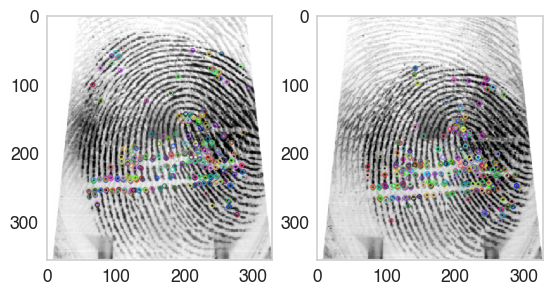

In [34]:
img1 = cv2.imread(path_train, 0)
img2 = cv2.imread(path_test, 0)

edges1, desc1 = edge_processing(img1, threshold=155) 
edges2, desc2 = edge_processing(img2, threshold=155)

plot_edges(img1, img2, edges1, edges2)

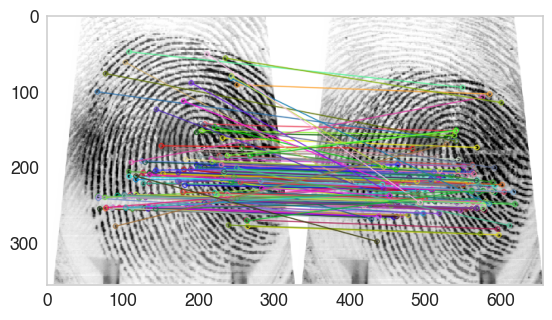

In [35]:
matches = match_edge_descriptors(desc1, desc2)

plot_matches(img1, img2, edges1, edges2, matches)

In [43]:
# 查看features文件夹中的一个.npy文件内容
import numpy as np
import os

# 选择一个特征文件（例如user_000）
feature_file = '../features/user_000_features.npy'

if os.path.exists(feature_file):
    # 加载特征文件
    features = np.load(feature_file, allow_pickle=True)
    
    print(f"文件: {feature_file}")
    print(f"数据类型: {type(features)}")
    print(f"数组形状: {features.shape}")
    print(f"数组类型: {features.dtype}")
    print(f"\n特征数组内容:")
    print("=" * 80)
    
    # 打印每个样本的特征
    for i, sample_features in enumerate(features):
        print(f"\n样本 {i}:")
        print(f"  形状: {sample_features.shape}")
        print(f"  特征数量: {len(sample_features)}")
        print(f"  前5个特征点:")
        print(f"    [x, y, orientation, type]")
        for j, feature in enumerate(sample_features[:5]):
            print(f"    {j+1}. {feature}")
        if len(sample_features) > 5:
            print(f"    ... (还有 {len(sample_features) - 5} 个特征点)")
        print(f"  特征统计:")
        print(f"    x坐标范围: [{np.min(sample_features[:, 0]):.1f}, {np.max(sample_features[:, 0]):.1f}]")
        print(f"    y坐标范围: [{np.min(sample_features[:, 1]):.1f}, {np.max(sample_features[:, 1]):.1f}]")
        print(f"    方向范围: [{np.min(sample_features[:, 2]):.1f}°, {np.max(sample_features[:, 2]):.1f}°]")
        print(f"    类型分布: 终止点(1)={np.sum(sample_features[:, 3] == 1)}, 分叉点(3)={np.sum(sample_features[:, 3] == 3)}")
    
    print("\n" + "=" * 80)
    print(f"总共 {len(features)} 个训练样本")
else:
    print(f"文件不存在: {feature_file}")


文件: ../features/user_000_features.npy
数据类型: <class 'numpy.ndarray'>
数组形状: (3,)
数组类型: object

特征数组内容:

样本 0:
  形状: (85, 4)
  特征数量: 85
  前5个特征点:
    [x, y, orientation, type]
    1. [258.        32.        70.892235   1.      ]
    2. [135.       33.      174.78378   1.     ]
    3. [163.         33.          6.6201105   1.       ]
    4. [234.        35.        48.591213   1.      ]
    5. [252.        51.        56.485844   1.      ]
    ... (还有 80 个特征点)
  特征统计:
    x坐标范围: [29.0, 318.0]
    y坐标范围: [32.0, 347.0]
    方向范围: [0.8°, 177.6°]
    类型分布: 终止点(1)=84, 分叉点(3)=1

样本 1:
  形状: (100, 4)
  特征数量: 100
  前5个特征点:
    [x, y, orientation, type]
    1. [ 72.       20.      157.79022   1.     ]
    2. [277.       21.      174.10149   1.     ]
    3. [111.       25.      172.78983   1.     ]
    4. [181.       26.       19.37785   1.     ]
    5. [234.       35.       46.06432   1.     ]
    ... (还有 95 个特征点)
  特征统计:
    x坐标范围: [30.0, 314.0]
    y坐标范围: [20.0, 344.0]
    方向范围: [0.2°, 176.4°]
    类

Minutiae Extraction Process Visualization

Step 1: Extract minutiae (Crossing Number method)
  Extraction result: 387 terminations, 37 bifurcations

Step 2: Border cleaning (Clean minutiae)
  After cleaning: 269 terminations, 33 bifurcations
  Removed: 118 terminations, 4 bifurcations

Step 3: Remove duplicate points (Remove duplicate minutiae)
  Before removal: 302 minutiae
  After removal: 171 minutiae
  Removed: 131 duplicate points

Step 4: Eliminate false minutiae (Eliminate false minutiae)
  Before elimination: 171 minutiae
  After elimination: 85 minutiae
  Eliminated: 86 false minutiae


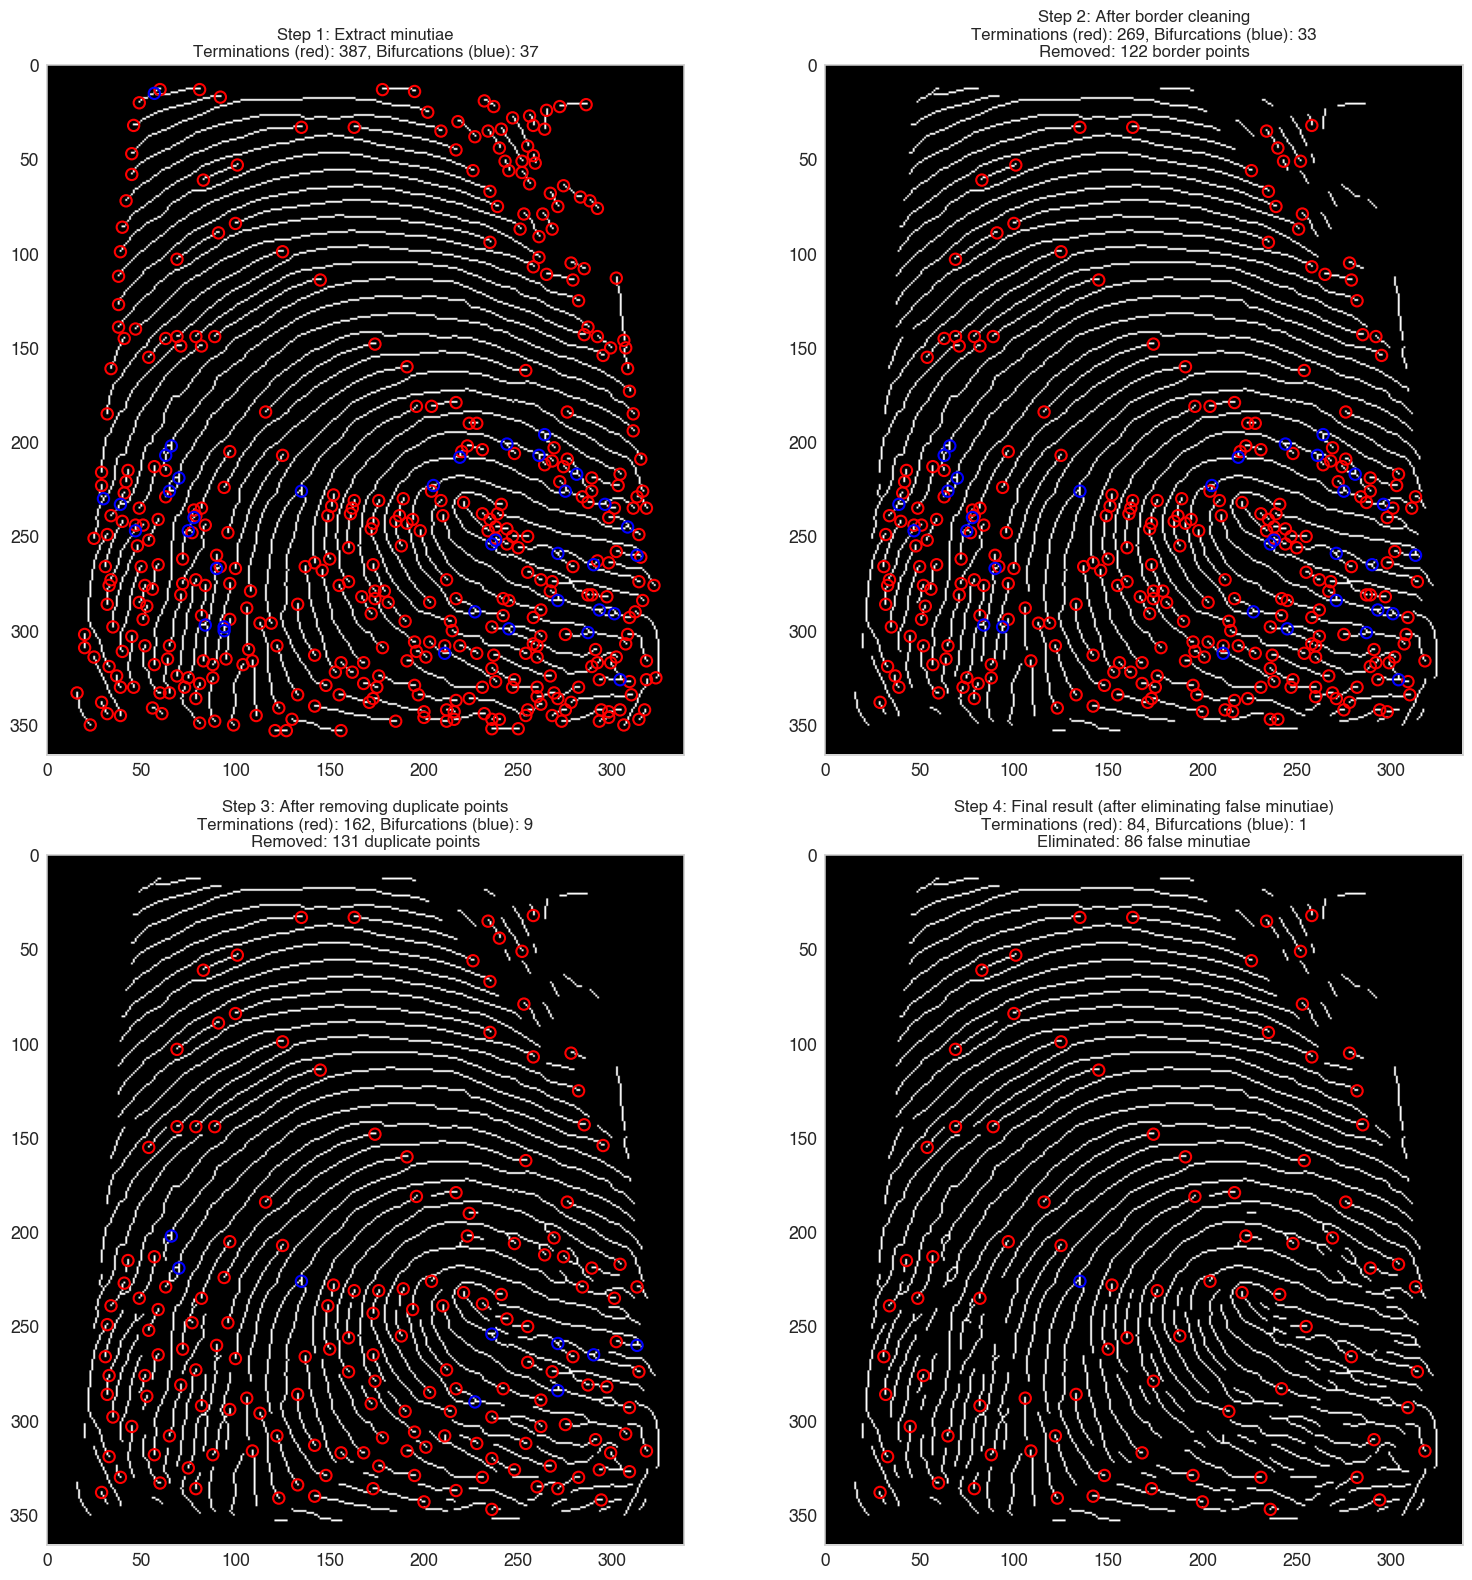


Statistical Summary
Raw extraction: 424 minutiae
   - Terminations: 387
   - Bifurcations: 37

After border cleaning: 302 minutiae
   - Terminations: 269
   - Bifurcations: 33

After removing duplicates: 171 minutiae
   - Terminations: 162
   - Bifurcations: 9

Final result: 85 minutiae
   - Terminations: 84
   - Bifurcations: 1

Total removed: 339 minutiae


In [45]:
# Visualize each step of process_minutiae
import numpy as np
import matplotlib.pyplot as plt
from libs.basics import load_image
from libs.enhancing import enhance_image
from libs.minutiae import extract_minutiae, clean_minutiae, remove_duplicate_minutiae, eliminate_false_minutiae, plot_minutiae

# Load a fingerprint image
image_path = '../Project-Data/train/000_R0_0.bmp'
img = load_image(image_path, True)

# Image enhancement
img_enhanced = enhance_image(img, padding=5)

print("=" * 80)
print("Minutiae Extraction Process Visualization")
print("=" * 80)

# Step 1: Extract minutiae (CN method)
print("\nStep 1: Extract minutiae (Crossing Number method)")
terminations_raw, bifurcations_raw = extract_minutiae(img_enhanced)
print(f"  Extraction result: {len(terminations_raw)} terminations, {len(bifurcations_raw)} bifurcations")

# Step 2: Border cleaning
print("\nStep 2: Border cleaning (Clean minutiae)")
terminations_cleaned = clean_minutiae(img_enhanced, terminations_raw)
bifurcations_cleaned = clean_minutiae(img_enhanced, bifurcations_raw)
print(f"  After cleaning: {len(terminations_cleaned)} terminations, {len(bifurcations_cleaned)} bifurcations")
print(f"  Removed: {len(terminations_raw) - len(terminations_cleaned)} terminations, {len(bifurcations_raw) - len(bifurcations_cleaned)} bifurcations")

# Step 3: Remove duplicate points
print("\nStep 3: Remove duplicate points (Remove duplicate minutiae)")
all_minutiae_before_dup = terminations_cleaned + bifurcations_cleaned
all_minutiae_after_dup = remove_duplicate_minutiae(all_minutiae_before_dup, min_distance=10)
print(f"  Before removal: {len(all_minutiae_before_dup)} minutiae")
print(f"  After removal: {len(all_minutiae_after_dup)} minutiae")
print(f"  Removed: {len(all_minutiae_before_dup) - len(all_minutiae_after_dup)} duplicate points")

# Separate terminations and bifurcations (for visualization)
terminations_after_dup = [m for m in all_minutiae_after_dup if m in terminations_cleaned]
bifurcations_after_dup = [m for m in all_minutiae_after_dup if m in bifurcations_cleaned]

# Step 4: Eliminate false minutiae
print("\nStep 4: Eliminate false minutiae (Eliminate false minutiae)")
all_minutiae_final = eliminate_false_minutiae(all_minutiae_after_dup, min_distance=15, max_neighbors=3)
print(f"  Before elimination: {len(all_minutiae_after_dup)} minutiae")
print(f"  After elimination: {len(all_minutiae_final)} minutiae")
print(f"  Eliminated: {len(all_minutiae_after_dup) - len(all_minutiae_final)} false minutiae")

# Separate final results
terminations_final = [m for m in all_minutiae_final if m in terminations_after_dup]
bifurcations_final = [m for m in all_minutiae_final if m in bifurcations_after_dup]

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# Step 1: Raw extraction results
ax = axes[0, 0]
ax.imshow(img_enhanced, cmap='gray')
ax.set_title(f'Step 1: Extract minutiae\nTerminations (red): {len(terminations_raw)}, Bifurcations (blue): {len(bifurcations_raw)}', 
             fontsize=12, fontweight='bold')
ax.grid(False)
for y, x in terminations_raw:
    circle = plt.Circle((x, y), radius=3, linewidth=1.5, color='red', fill=False)
    ax.add_patch(circle)
for y, x in bifurcations_raw:
    circle = plt.Circle((x, y), radius=3, linewidth=1.5, color='blue', fill=False)
    ax.add_patch(circle)
ax.set_xlim(0, img_enhanced.shape[1])
ax.set_ylim(img_enhanced.shape[0], 0)

# Step 2: After border cleaning
ax = axes[0, 1]
ax.imshow(img_enhanced, cmap='gray')
ax.set_title(f'Step 2: After border cleaning\nTerminations (red): {len(terminations_cleaned)}, Bifurcations (blue): {len(bifurcations_cleaned)}\nRemoved: {len(terminations_raw) + len(bifurcations_raw) - len(terminations_cleaned) - len(bifurcations_cleaned)} border points', 
             fontsize=12, fontweight='bold')
ax.grid(False)
for y, x in terminations_cleaned:
    circle = plt.Circle((x, y), radius=3, linewidth=1.5, color='red', fill=False)
    ax.add_patch(circle)
for y, x in bifurcations_cleaned:
    circle = plt.Circle((x, y), radius=3, linewidth=1.5, color='blue', fill=False)
    ax.add_patch(circle)
ax.set_xlim(0, img_enhanced.shape[1])
ax.set_ylim(img_enhanced.shape[0], 0)

# Step 3: After removing duplicate points
ax = axes[1, 0]
ax.imshow(img_enhanced, cmap='gray')
ax.set_title(f'Step 3: After removing duplicate points\nTerminations (red): {len(terminations_after_dup)}, Bifurcations (blue): {len(bifurcations_after_dup)}\nRemoved: {len(all_minutiae_before_dup) - len(all_minutiae_after_dup)} duplicate points', 
             fontsize=12, fontweight='bold')
ax.grid(False)
for y, x in terminations_after_dup:
    circle = plt.Circle((x, y), radius=3, linewidth=1.5, color='red', fill=False)
    ax.add_patch(circle)
for y, x in bifurcations_after_dup:
    circle = plt.Circle((x, y), radius=3, linewidth=1.5, color='blue', fill=False)
    ax.add_patch(circle)
ax.set_xlim(0, img_enhanced.shape[1])
ax.set_ylim(img_enhanced.shape[0], 0)

# Step 4: Final result (after eliminating false minutiae)
ax = axes[1, 1]
ax.imshow(img_enhanced, cmap='gray')
ax.set_title(f'Step 4: Final result (after eliminating false minutiae)\nTerminations (red): {len(terminations_final)}, Bifurcations (blue): {len(bifurcations_final)}\nEliminated: {len(all_minutiae_after_dup) - len(all_minutiae_final)} false minutiae', 
             fontsize=12, fontweight='bold')
ax.grid(False)
for y, x in terminations_final:
    circle = plt.Circle((x, y), radius=3, linewidth=1.5, color='red', fill=False)
    ax.add_patch(circle)
for y, x in bifurcations_final:
    circle = plt.Circle((x, y), radius=3, linewidth=1.5, color='blue', fill=False)
    ax.add_patch(circle)
ax.set_xlim(0, img_enhanced.shape[1])
ax.set_ylim(img_enhanced.shape[0], 0)

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "=" * 80)
print("Statistical Summary")
print("=" * 80)
print(f"Raw extraction: {len(terminations_raw) + len(bifurcations_raw)} minutiae")
print(f"   - Terminations: {len(terminations_raw)}")
print(f"   - Bifurcations: {len(bifurcations_raw)}")
print(f"\nAfter border cleaning: {len(terminations_cleaned) + len(bifurcations_cleaned)} minutiae")
print(f"   - Terminations: {len(terminations_cleaned)}")
print(f"   - Bifurcations: {len(bifurcations_cleaned)}")
print(f"\nAfter removing duplicates: {len(all_minutiae_after_dup)} minutiae")
print(f"   - Terminations: {len(terminations_after_dup)}")
print(f"   - Bifurcations: {len(bifurcations_after_dup)}")
print(f"\nFinal result: {len(all_minutiae_final)} minutiae")
print(f"   - Terminations: {len(terminations_final)}")
print(f"   - Bifurcations: {len(bifurcations_final)}")
print(f"\nTotal removed: {len(terminations_raw) + len(bifurcations_raw) - len(all_minutiae_final)} minutiae")
print("=" * 80)
